In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn.glm.first_level import (
    make_first_level_design_matrix,
)

In [4]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Proyecto_PINN_HRF"
)

SUBJECT_ID = "100206"

RAW_RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / SUBJECT_ID
    / "MNINonLinear"
    / "Results"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / SUBJECT_ID
)

REAL_MODEL_DIR = (
    PROCESSED_DIR
    / "real_model_inputs"
)

REAL_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "real"
    / SUBJECT_ID
    / "preprocessing"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

for directory in [
    REAL_MODEL_DIR,
    REAL_RESULTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

In [5]:
SCENARIOS = {
    "motor_lr_m1_left": {
        "run": "MOTOR_LR",
        "roi": "M1_left",
        "target_condition": "rh",
        "bold_column": "bold_m1_left_fraction",
        "bold_csv": (
            PROCESSED_DIR
            / "motor_lr_bilateral_bold.csv"
        ),
        "metadata": (
            PROCESSED_DIR
            / "motor_lr_metadata.json"
        ),
        "run_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_LR"
        ),
    },
    "motor_lr_m1_right": {
        "run": "MOTOR_LR",
        "roi": "M1_right",
        "target_condition": "lh",
        "bold_column": "bold_m1_right_fraction",
        "bold_csv": (
            PROCESSED_DIR
            / "motor_lr_bilateral_bold.csv"
        ),
        "metadata": (
            PROCESSED_DIR
            / "motor_lr_metadata.json"
        ),
        "run_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_LR"
        ),
    },
    "motor_rl_m1_left": {
        "run": "MOTOR_RL",
        "roi": "M1_left",
        "target_condition": "rh",
        "bold_column": "bold_m1_left_fraction",
        "bold_csv": (
            PROCESSED_DIR
            / "motor_rl_bilateral_bold.csv"
        ),
        "metadata": (
            PROCESSED_DIR
            / "motor_rl_metadata.json"
        ),
        "run_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_RL"
        ),
    },
    "motor_rl_m1_right": {
        "run": "MOTOR_RL",
        "roi": "M1_right",
        "target_condition": "lh",
        "bold_column": "bold_m1_right_fraction",
        "bold_csv": (
            PROCESSED_DIR
            / "motor_rl_bilateral_bold.csv"
        ),
        "metadata": (
            PROCESSED_DIR
            / "motor_rl_metadata.json"
        ),
        "run_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_RL"
        ),
    },
}

for scenario_name, config in SCENARIOS.items():
    print(f"\n{scenario_name}")

    for key in [
        "bold_csv",
        "metadata",
        "run_dir",
    ]:
        path = config[key]
        print(key, path.exists(), path)


motor_lr_m1_left
bold_csv True /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_lr_bilateral_bold.csv
metadata True /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_lr_metadata.json
run_dir True /content/drive/MyDrive/Proyecto_PINN_HRF/data/raw/100206/MNINonLinear/Results/tfMRI_MOTOR_LR

motor_lr_m1_right
bold_csv True /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_lr_bilateral_bold.csv
metadata True /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_lr_metadata.json
run_dir True /content/drive/MyDrive/Proyecto_PINN_HRF/data/raw/100206/MNINonLinear/Results/tfMRI_MOTOR_LR

motor_rl_m1_left
bold_csv True /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_rl_bilateral_bold.csv
metadata True /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_rl_metadata.json
run_dir True /content/drive/MyDrive/Proyecto_PINN_HRF/data/raw/100206/MNINonLinear/Results/tfMRI_MOTOR_RL

motor_rl_m1

In [6]:
ALL_CONDITIONS = [
    "cue",
    "lf",
    "lh",
    "rf",
    "rh",
    "t",
]

In [7]:
def cargar_eventos(
    events_dir: Path,
    conditions: list[str],
) -> pd.DataFrame:
    tables = []

    for condition in conditions:
        event_path = (
            events_dir
            / f"{condition}.txt"
        )

        if not event_path.exists():
            raise FileNotFoundError(
                event_path
            )

        values = np.loadtxt(
            event_path,
            ndmin=2,
        )

        table = pd.DataFrame(
            {
                "onset": values[:, 0],
                "duration": values[:, 1],
                "trial_type": condition,
                "modulation": values[:, 2],
            }
        )

        tables.append(table)

    return (
        pd.concat(
            tables,
            ignore_index=True,
        )
        .sort_values("onset")
        .reset_index(drop=True)
    )

In [8]:
def cargar_movimiento(
    movement_path: Path,
    n_volumes: int,
) -> pd.DataFrame:
    movement = np.loadtxt(
        movement_path,
        ndmin=2,
    )

    if movement.shape[0] != n_volumes:
        raise ValueError(
            f"Se esperaban {n_volumes} filas, "
            f"pero se encontraron {movement.shape[0]}."
        )

    if movement.shape[1] < 12:
        raise ValueError(
            "El archivo contiene menos "
            "de 12 regresores."
        )

    movement = movement[:, :12]

    columns = [
        "trans_x",
        "trans_y",
        "trans_z",
        "rot_x",
        "rot_y",
        "rot_z",
        "d_trans_x",
        "d_trans_y",
        "d_trans_z",
        "d_rot_x",
        "d_rot_y",
        "d_rot_z",
    ]

    return pd.DataFrame(
        movement,
        columns=columns,
    )

In [9]:
SECONDS_BEFORE = 2.0
SECONDS_AFTER = 20.0

In [10]:
def construir_ventanas_objetivo(
    frame_times: np.ndarray,
    target_events: pd.DataFrame,
) -> tuple[list[dict], np.ndarray]:
    target_events = (
        target_events
        .sort_values("onset")
        .reset_index(drop=True)
    )

    if len(target_events) != 2:
        raise ValueError(
            "Se esperaban exactamente dos "
            "bloques de la condición objetivo."
        )

    windows = []
    combined_mask = np.zeros(
        len(frame_times),
        dtype=bool,
    )

    for block_index, event in (
        target_events.iterrows()
    ):
        onset = float(
            event["onset"]
        )

        duration = float(
            event["duration"]
        )

        start = max(
            float(frame_times[0]),
            onset - SECONDS_BEFORE,
        )

        end = min(
            float(frame_times[-1]),
            onset
            + duration
            + SECONDS_AFTER,
        )

        mask = (
            (frame_times >= start)
            & (frame_times <= end)
        )

        combined_mask |= mask

        windows.append(
            {
                "block": block_index + 1,
                "onset_s": onset,
                "duration_s": duration,
                "start_s": start,
                "end_s": end,
                "mask": mask,
            }
        )

    return windows, combined_mask

In [11]:
def construir_diseño_nuisance(
    frame_times: np.ndarray,
    nuisance_events: pd.DataFrame,
    movement: pd.DataFrame,
) -> pd.DataFrame:
    return make_first_level_design_matrix(
        frame_times=frame_times,
        events=nuisance_events,
        hrf_model="spm",
        drift_model="cosine",
        high_pass=0.008,
        add_regs=movement.to_numpy(),
        add_reg_names=list(
            movement.columns
        ),
        min_onset=-24,
    )

In [12]:
def ajustar_nuisance(
    design_matrix: pd.DataFrame,
    bold_signal: np.ndarray,
    excluded_mask: np.ndarray,
) -> dict:
    X = design_matrix.to_numpy(
        dtype=float,
    )

    y = np.asarray(
        bold_signal,
        dtype=float,
    )

    fitting_mask = ~excluded_mask

    if fitting_mask.sum() <= X.shape[1]:
        raise ValueError(
            "No existen suficientes puntos "
            "para ajustar el modelo nuisance."
        )

    beta, _, rank, _ = np.linalg.lstsq(
        X[fitting_mask],
        y[fitting_mask],
        rcond=None,
    )

    nuisance_prediction = X @ beta

    adjusted_signal = (
        y - nuisance_prediction
    )

    condition_number = float(
        np.linalg.cond(
            X[fitting_mask]
        )
    )

    return {
        "beta": beta,
        "prediction": nuisance_prediction,
        "adjusted_signal": adjusted_signal,
        "fitting_mask": fitting_mask,
        "rank": int(rank),
        "condition_number": condition_number,
    }

In [13]:
def extraer_bloques(
    frame_times: np.ndarray,
    adjusted_signal: np.ndarray,
    windows: list[dict],
    scenario_name: str,
    run_name: str,
    roi_name: str,
    target_condition: str,
) -> pd.DataFrame:
    block_tables = []

    for window in windows:
        mask = window["mask"]

        relative_time = (
            frame_times[mask]
            - window["onset_s"]
        )

        block_signal = (
            adjusted_signal[mask]
        )

        prestimulus_mask = (
            relative_time < 0.0
        )

        if prestimulus_mask.sum() == 0:
            raise RuntimeError(
                "La ventana no contiene "
                "puntos preestímulo."
            )

        baseline = float(
            np.mean(
                block_signal[
                    prestimulus_mask
                ]
            )
        )

        baseline_corrected = (
            block_signal - baseline
        )

        stimulus = (
            (
                relative_time >= 0.0
            )
            & (
                relative_time
                < window["duration_s"]
            )
        ).astype(float)

        block_table = pd.DataFrame(
            {
                "scenario": scenario_name,
                "run": run_name,
                "roi": roi_name,
                "target_condition": (
                    target_condition
                ),
                "block": window["block"],
                "time_s": frame_times[mask],
                "relative_time_s": relative_time,
                "stimulus": stimulus,
                "bold_adjusted_fraction": (
                    block_signal
                ),
                "baseline_fraction": baseline,
                "bold_baseline_corrected_fraction": (
                    baseline_corrected
                ),
                "bold_baseline_corrected_percent": (
                    100.0
                    * baseline_corrected
                ),
            }
        )

        block_tables.append(
            block_table
        )

    return pd.concat(
        block_tables,
        ignore_index=True,
    )

In [14]:
summary_rows = []
all_blocks = []

for scenario_name, config in (
    SCENARIOS.items()
):
    bold_table = pd.read_csv(
        config["bold_csv"]
    )

    with open(
        config["metadata"],
        encoding="utf-8",
    ) as file:
        metadata = json.load(file)

    n_volumes = int(
        metadata["n_volumes"]
    )

    tr_s = float(
        metadata["tr_s"]
    )

    frame_times = (
        np.arange(
            n_volumes,
            dtype=float,
        )
        * tr_s
    )

    bold_signal = (
        bold_table[
            config["bold_column"]
        ].to_numpy(dtype=float)
    )

    events_dir = (
        config["run_dir"]
        / "EVs"
    )

    all_events = cargar_eventos(
        events_dir,
        ALL_CONDITIONS,
    )

    target_events = all_events.loc[
        all_events["trial_type"]
        == config["target_condition"]
    ].copy()

    nuisance_events = all_events.loc[
        all_events["trial_type"]
        != config["target_condition"]
    ].copy()

    movement = cargar_movimiento(
        config["run_dir"]
        / "Movement_Regressors.txt",
        n_volumes=n_volumes,
    )

    windows, target_window_mask = (
        construir_ventanas_objetivo(
            frame_times,
            target_events,
        )
    )

    nuisance_design = (
        construir_diseño_nuisance(
            frame_times,
            nuisance_events,
            movement,
        )
    )

    nuisance_result = ajustar_nuisance(
        design_matrix=nuisance_design,
        bold_signal=bold_signal,
        excluded_mask=target_window_mask,
    )

    adjusted_signal = nuisance_result[
        "adjusted_signal"
    ]

    full_table = pd.DataFrame(
        {
            "time_s": frame_times,
            "bold_original_fraction": (
                bold_signal
            ),
            "nuisance_prediction_fraction": (
                nuisance_result[
                    "prediction"
                ]
            ),
            "bold_adjusted_fraction": (
                adjusted_signal
            ),
            "nuisance_fit_mask": (
                nuisance_result[
                    "fitting_mask"
                ].astype(int)
            ),
            "target_window_mask": (
                target_window_mask.astype(int)
            ),
        }
    )

    full_table.to_csv(
        REAL_MODEL_DIR
        / f"{scenario_name}_full.csv",
        index=False,
    )

    nuisance_design.to_csv(
        REAL_MODEL_DIR
        / f"{scenario_name}_nuisance_design.csv",
        index=True,
        index_label="time_s",
    )

    block_table = extraer_bloques(
        frame_times=frame_times,
        adjusted_signal=adjusted_signal,
        windows=windows,
        scenario_name=scenario_name,
        run_name=config["run"],
        roi_name=config["roi"],
        target_condition=config[
            "target_condition"
        ],
    )

    block_table.to_csv(
        REAL_MODEL_DIR
        / f"{scenario_name}_blocks.csv",
        index=False,
    )

    all_blocks.append(
        block_table
    )

    first_block = block_table.loc[
        block_table["block"] == 1
    ].copy()

    second_block = block_table.loc[
        block_table["block"] == 2
    ].copy()

    common_length = min(
        len(first_block),
        len(second_block),
    )

    first_values = (
        first_block[
            "bold_baseline_corrected_fraction"
        ]
        .to_numpy(dtype=float)[:common_length]
    )

    second_values = (
        second_block[
            "bold_baseline_corrected_fraction"
        ]
        .to_numpy(dtype=float)[:common_length]
    )

    block_correlation = (
        np.corrcoef(
            first_values,
            second_values,
        )[0, 1]
    )

    outside_std = float(
        np.std(
            adjusted_signal[
                ~target_window_mask
            ],
            ddof=0,
        )
    )

    summary_rows.append(
        {
            "scenario": scenario_name,
            "run": config["run"],
            "roi": config["roi"],
            "target_condition": (
                config[
                    "target_condition"
                ]
            ),
            "nuisance_rank": (
                nuisance_result["rank"]
            ),
            "nuisance_columns": (
                nuisance_design.shape[1]
            ),
            "nuisance_condition_number": (
                nuisance_result[
                    "condition_number"
                ]
            ),
            "nuisance_fit_points": int(
                nuisance_result[
                    "fitting_mask"
                ].sum()
            ),
            "block_1_points": len(
                first_block
            ),
            "block_2_points": len(
                second_block
            ),
            "block_1_peak_percent": float(
                first_block[
                    "bold_baseline_corrected_percent"
                ].max()
            ),
            "block_2_peak_percent": float(
                second_block[
                    "bold_baseline_corrected_percent"
                ].max()
            ),
            "block_1_minimum_percent": float(
                first_block[
                    "bold_baseline_corrected_percent"
                ].min()
            ),
            "block_2_minimum_percent": float(
                second_block[
                    "bold_baseline_corrected_percent"
                ].min()
            ),
            "block_correlation": float(
                block_correlation
            ),
            "adjusted_baseline_std_percent": (
                100.0 * outside_std
            ),
        }
    )

[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.

[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.

[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.

[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.

In [15]:
real_blocks = pd.concat(
    all_blocks,
    ignore_index=True,
)

real_summary = pd.DataFrame(
    summary_rows
)

real_blocks.to_csv(
    REAL_RESULTS_DIR
    / "real_target_blocks.csv",
    index=False,
)

real_summary.to_csv(
    REAL_RESULTS_DIR
    / "real_preprocessing_summary.csv",
    index=False,
)

display(real_summary)

,scenario,run,roi,target_condition,nuisance_rank,nuisance_columns,nuisance_condition_number,nuisance_fit_points,block_1_points,block_2_points,block_1_peak_percent,block_2_peak_percent,block_1_minimum_percent,block_2_minimum_percent,block_correlation,adjusted_baseline_std_percent
0,motor_lr_m1_left,MOTOR_LR,M1_left,rh,21,21,195.434751,190,47,47,1.464550,1.181723,-0.490595,-1.210489,0.603206,0.340013
1,motor_lr_m1_right,MOTOR_LR,M1_right,lh,21,21,179.785284,190,47,47,0.668576,1.748893,-0.960120,-0.093497,0.231654,0.343129
2,motor_rl_m1_left,MOTOR_RL,M1_left,rh,21,21,225.283874,190,47,47,1.400921,2.048855,-1.497818,-0.683805,0.719916,0.326497
3,motor_rl_m1_right,MOTOR_RL,M1_right,lh,21,21,214.891130,190,47,47,1.587111,2.288427,-0.378606,-0.333741,0.716425,0.374046


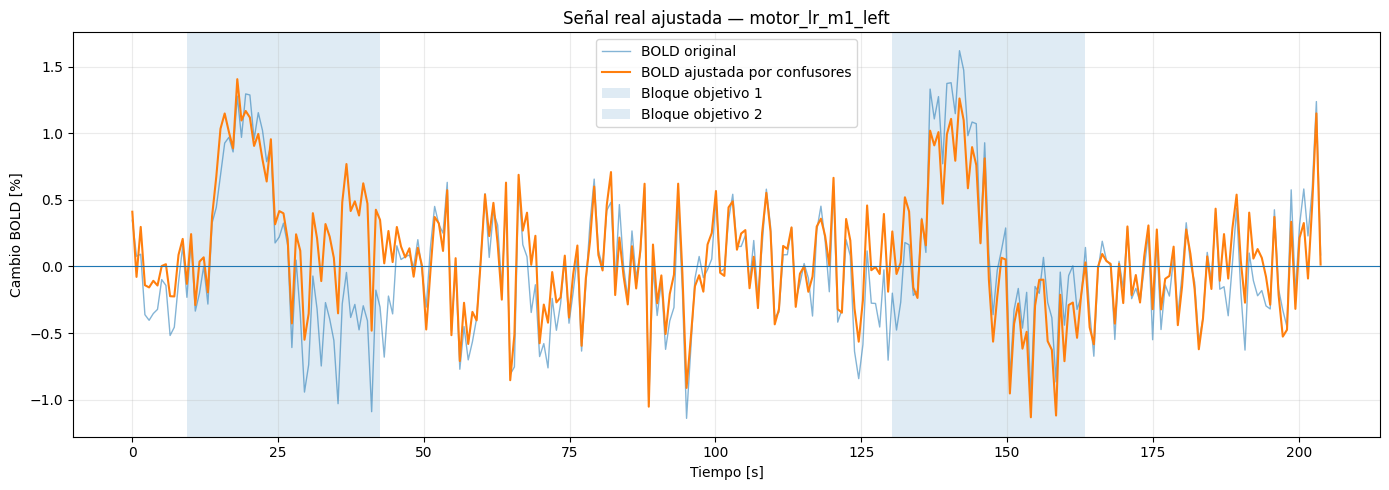

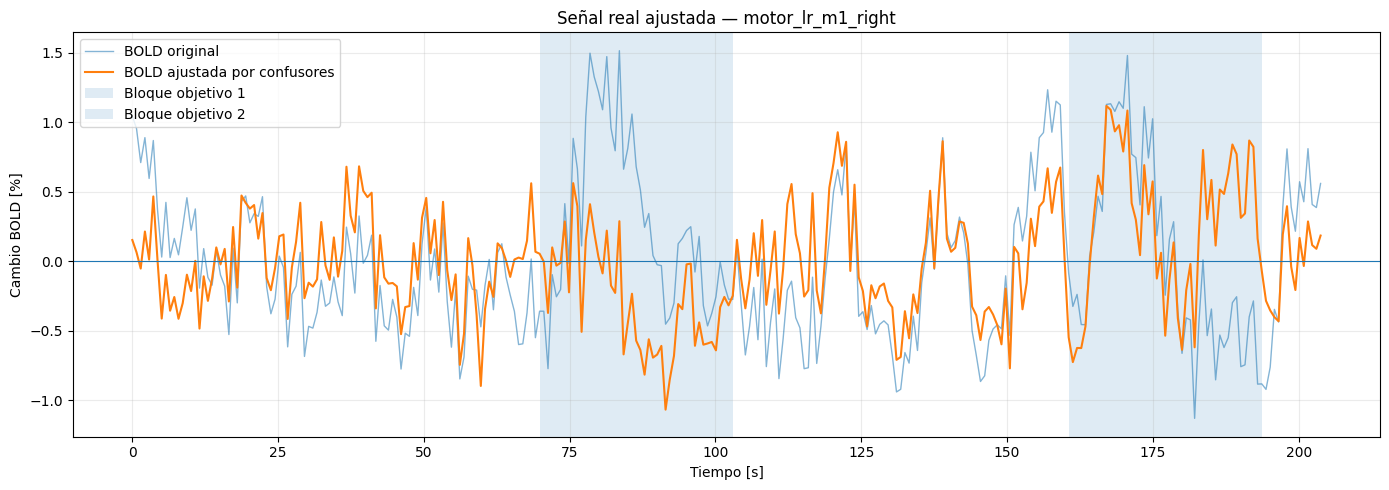

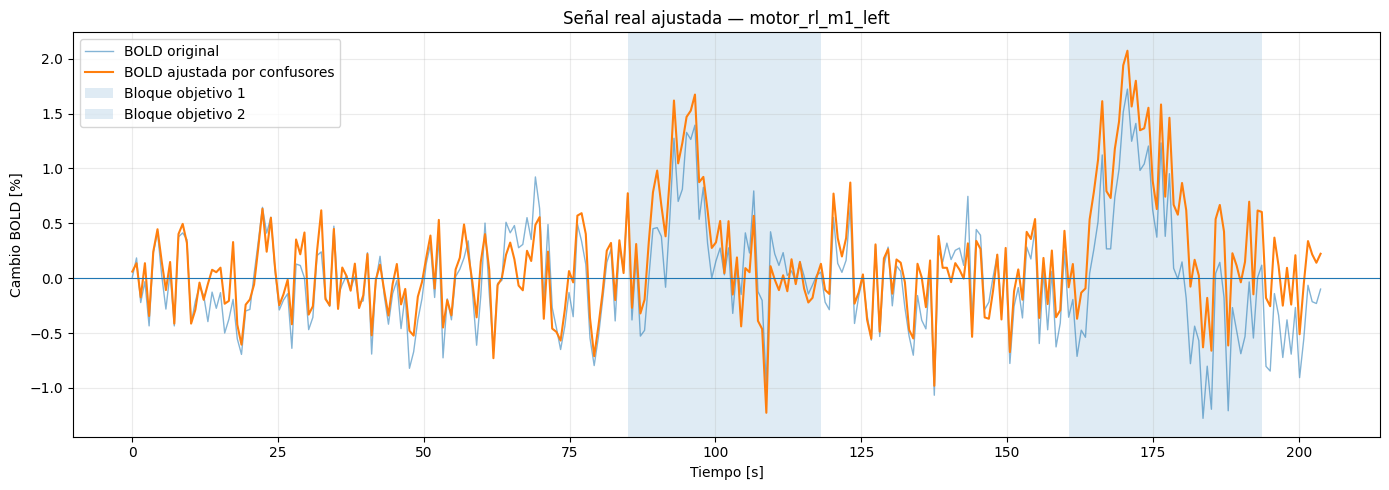

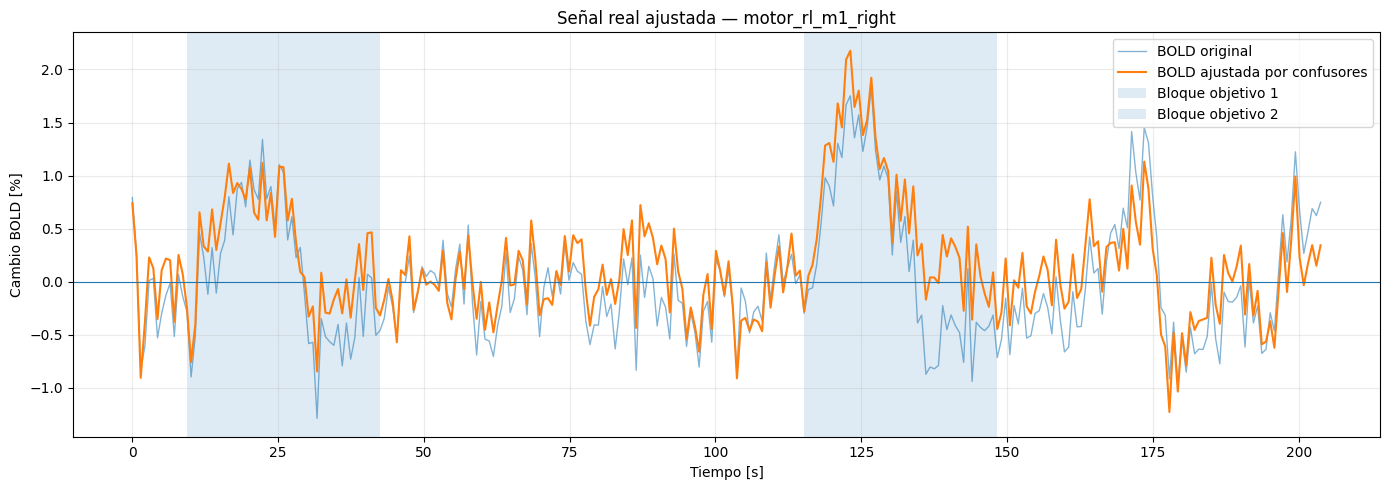

In [16]:
for scenario_name in SCENARIOS:
    full_table = pd.read_csv(
        REAL_MODEL_DIR
        / f"{scenario_name}_full.csv"
    )

    blocks = pd.read_csv(
        REAL_MODEL_DIR
        / f"{scenario_name}_blocks.csv"
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        full_table["time_s"],
        100.0
        * full_table[
            "bold_original_fraction"
        ],
        linewidth=1.0,
        alpha=0.55,
        label="BOLD original",
    )

    plt.plot(
        full_table["time_s"],
        100.0
        * full_table[
            "bold_adjusted_fraction"
        ],
        linewidth=1.5,
        label="BOLD ajustada por confusores",
    )

    for block_number in [1, 2]:
        block = blocks.loc[
            blocks["block"]
            == block_number
        ]

        plt.axvspan(
            float(block["time_s"].min()),
            float(block["time_s"].max()),
            alpha=0.14,
            label=(
                f"Bloque objetivo {block_number}"
            ),
        )

    plt.axhline(
        0.0,
        linewidth=0.8,
    )

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Cambio BOLD [%]")
    plt.title(
        f"Señal real ajustada — {scenario_name}"
    )
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / f"real_adjusted_{scenario_name}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

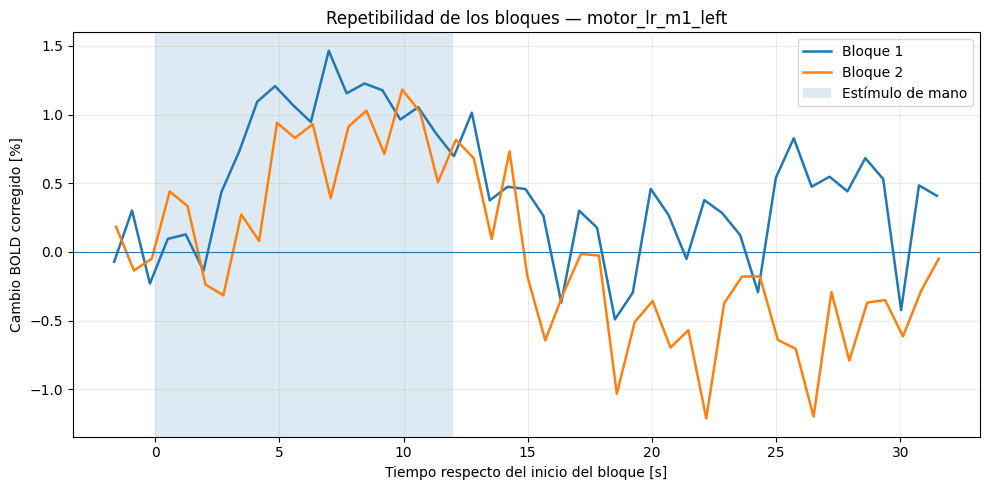

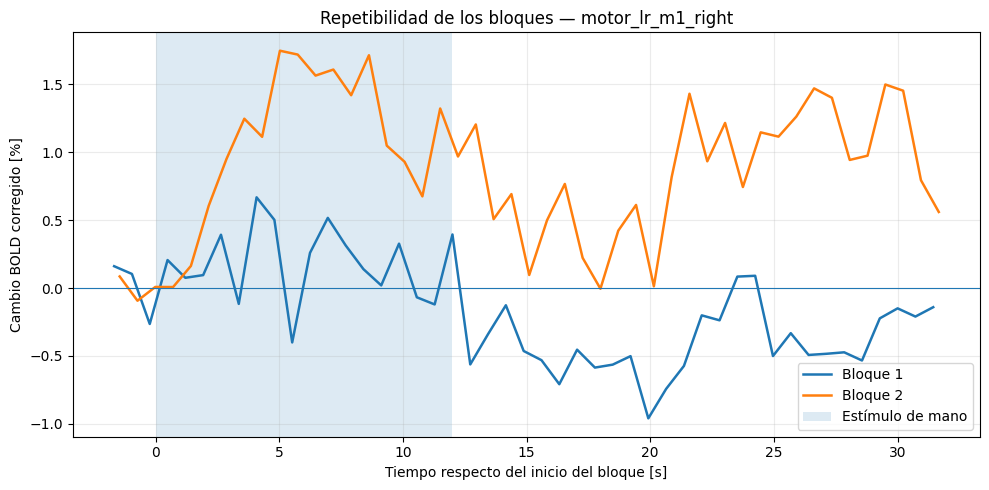

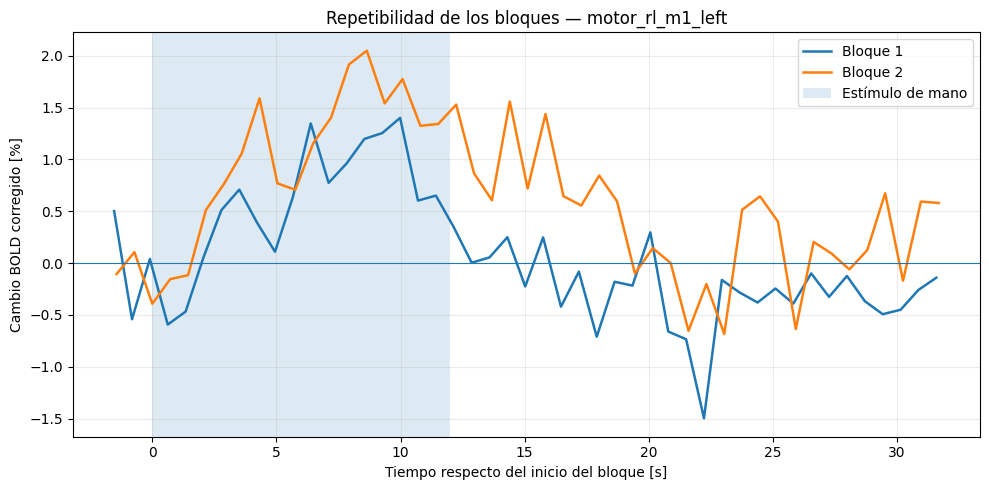

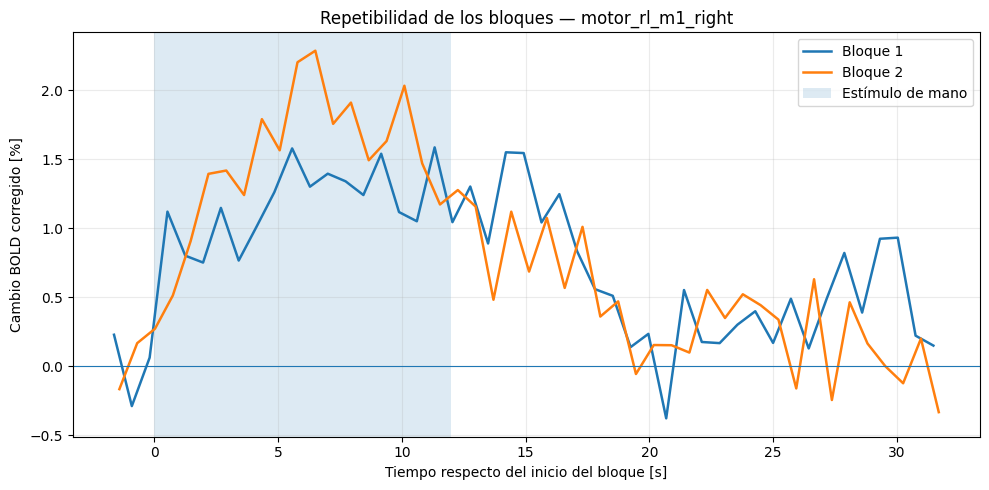

In [17]:
for scenario_name in SCENARIOS:
    blocks = pd.read_csv(
        REAL_MODEL_DIR
        / f"{scenario_name}_blocks.csv"
    )

    plt.figure(figsize=(10, 5))

    for block_number in [1, 2]:
        selected = blocks.loc[
            blocks["block"]
            == block_number
        ]

        plt.plot(
            selected["relative_time_s"],
            selected[
                "bold_baseline_corrected_percent"
            ],
            linewidth=1.8,
            label=f"Bloque {block_number}",
        )

    duration_s = float(
        blocks["stimulus"].groupby(
            blocks["block"]
        ).sum().iloc[0]
    )

    plt.axvspan(
        0.0,
        12.0,
        alpha=0.15,
        label="Estímulo de mano",
    )

    plt.axhline(
        0.0,
        linewidth=0.8,
    )

    plt.xlabel(
        "Tiempo respecto del inicio del bloque [s]"
    )
    plt.ylabel(
        "Cambio BOLD corregido [%]"
    )
    plt.title(
        f"Repetibilidad de los bloques — {scenario_name}"
    )
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / f"real_blocks_{scenario_name}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [18]:
def calcular_correlacion_con_desfase(
    first_signal: np.ndarray,
    second_signal: np.ndarray,
    maximum_lag_volumes: int = 4,
) -> dict:
    """
    Calcula la correlación entre bloques permitiendo un desfase
    de hasta maximum_lag_volumes.

    Un desfase positivo indica que el segundo bloque se desplaza
    hacia tiempos posteriores.
    """
    first_signal = np.asarray(
        first_signal,
        dtype=float,
    )

    second_signal = np.asarray(
        second_signal,
        dtype=float,
    )

    correlations = []

    for lag in range(
        -maximum_lag_volumes,
        maximum_lag_volumes + 1,
    ):
        if lag < 0:
            first = first_signal[-lag:]
            second = second_signal[:lag]

        elif lag > 0:
            first = first_signal[:-lag]
            second = second_signal[lag:]

        else:
            first = first_signal
            second = second_signal

        if (
            len(first) < 3
            or np.std(first) < 1e-12
            or np.std(second) < 1e-12
        ):
            correlation = np.nan
        else:
            correlation = float(
                np.corrcoef(
                    first,
                    second,
                )[0, 1]
            )

        correlations.append(
            {
                "lag_volumes": lag,
                "correlation": correlation,
            }
        )

    correlation_table = pd.DataFrame(
        correlations
    ).dropna()

    best_row = correlation_table.loc[
        correlation_table[
            "correlation"
        ].idxmax()
    ]

    return {
        "zero_lag_correlation": float(
            correlation_table.loc[
                correlation_table[
                    "lag_volumes"
                ] == 0,
                "correlation",
            ].iloc[0]
        ),
        "best_lag_volumes": int(
            best_row["lag_volumes"]
        ),
        "best_lag_correlation": float(
            best_row["correlation"]
        ),
    }

In [19]:
quality_rows = []
modeling_tables = []

for scenario_name, config in SCENARIOS.items():

    blocks = pd.read_csv(
        REAL_MODEL_DIR
        / f"{scenario_name}_blocks.csv"
    )

    with open(
        config["metadata"],
        encoding="utf-8",
    ) as file:
        metadata = json.load(file)

    tr_s = float(
        metadata["tr_s"]
    )

    block_1 = (
        blocks.loc[
            blocks["block"] == 1
        ]
        .sort_values("relative_time_s")
        .reset_index(drop=True)
    )

    block_2 = (
        blocks.loc[
            blocks["block"] == 2
        ]
        .sort_values("relative_time_s")
        .reset_index(drop=True)
    )

    common_length = min(
        len(block_1),
        len(block_2),
    )

    # Para el control de forma se elimina solamente
    # la media de cada bloque, sin alterar su dinámica.
    signal_1 = (
        block_1[
            "bold_adjusted_fraction"
        ]
        .to_numpy(dtype=float)[:common_length]
    )

    signal_2 = (
        block_2[
            "bold_adjusted_fraction"
        ]
        .to_numpy(dtype=float)[:common_length]
    )

    centered_1 = signal_1 - np.mean(signal_1)
    centered_2 = signal_2 - np.mean(signal_2)

    lag_result = (
        calcular_correlacion_con_desfase(
            centered_1,
            centered_2,
            maximum_lag_volumes=4,
        )
    )

    response_1 = block_1.loc[
        (
            block_1["relative_time_s"] >= 0.0
        )
        & (
            block_1["relative_time_s"] <= 18.0
        ),
        "bold_adjusted_fraction",
    ].to_numpy(dtype=float)

    response_2 = block_2.loc[
        (
            block_2["relative_time_s"] >= 0.0
        )
        & (
            block_2["relative_time_s"] <= 18.0
        ),
        "bold_adjusted_fraction",
    ].to_numpy(dtype=float)

    peak_1_percent = float(
        100.0
        * (
            np.max(response_1)
            - np.median(signal_1)
        )
    )

    peak_2_percent = float(
        100.0
        * (
            np.max(response_2)
            - np.median(signal_2)
        )
    )

    baseline_std_percent = float(
        real_summary.loc[
            real_summary["scenario"]
            == scenario_name,
            "adjusted_baseline_std_percent",
        ].iloc[0]
    )

    mean_peak_percent = (
        peak_1_percent
        + peak_2_percent
    ) / 2.0

    response_to_noise_ratio = (
        mean_peak_percent
        / baseline_std_percent
    )

    if (
        lag_result[
            "best_lag_correlation"
        ] >= 0.60
    ):
        quality_label = "repetibilidad_buena"

    elif (
        lag_result[
            "best_lag_correlation"
        ] >= 0.30
    ):
        quality_label = "repetibilidad_moderada"

    else:
        quality_label = "repetibilidad_baja"

    quality_rows.append(
        {
            "scenario": scenario_name,
            "run": config["run"],
            "roi": config["roi"],
            "target_condition": (
                config["target_condition"]
            ),
            "zero_lag_correlation": (
                lag_result[
                    "zero_lag_correlation"
                ]
            ),
            "best_lag_correlation": (
                lag_result[
                    "best_lag_correlation"
                ]
            ),
            "best_lag_volumes": (
                lag_result[
                    "best_lag_volumes"
                ]
            ),
            "best_lag_seconds": (
                lag_result[
                    "best_lag_volumes"
                ]
                * tr_s
            ),
            "block_1_peak_percent_0_18s": (
                peak_1_percent
            ),
            "block_2_peak_percent_0_18s": (
                peak_2_percent
            ),
            "baseline_std_percent": (
                baseline_std_percent
            ),
            "response_to_noise_ratio": (
                response_to_noise_ratio
            ),
            "quality_label": quality_label,
        }
    )

    # Archivo definitivo para los modelos.
    modeling_table = blocks[
        [
            "scenario",
            "run",
            "roi",
            "target_condition",
            "block",
            "time_s",
            "relative_time_s",
            "stimulus",
            "bold_adjusted_fraction",
        ]
    ].copy()

    modeling_table = modeling_table.rename(
        columns={
            "bold_adjusted_fraction":
            "bold_observed_fraction"
        }
    )

    modeling_tables.append(
        modeling_table
    )

In [20]:
real_quality_summary = pd.DataFrame(
    quality_rows
)

real_modeling_blocks = pd.concat(
    modeling_tables,
    ignore_index=True,
)

real_quality_summary.to_csv(
    REAL_RESULTS_DIR
    / "real_quality_summary.csv",
    index=False,
)

real_modeling_blocks.to_csv(
    REAL_MODEL_DIR
    / "real_modeling_blocks.csv",
    index=False,
)

display(real_quality_summary)

,scenario,run,roi,target_condition,zero_lag_correlation,best_lag_correlation,best_lag_volumes,best_lag_seconds,block_1_peak_percent_0_18s,block_2_peak_percent_0_18s,baseline_std_percent,response_to_noise_ratio,quality_label
0,motor_lr_m1_left,MOTOR_LR,M1_left,rh,0.603206,0.646819,3,2.16,1.006756,1.316877,0.340013,3.416979,repetibilidad_buena
1,motor_lr_m1_right,MOTOR_LR,M1_right,lh,0.231654,0.306902,3,2.16,0.869786,0.804895,0.343129,2.440307,repetibilidad_moderada
2,motor_rl_m1_left,MOTOR_RL,M1_left,rh,0.719916,0.757821,1,0.72,1.500393,1.452974,0.326497,4.522805,repetibilidad_buena
3,motor_rl_m1_right,MOTOR_RL,M1_right,lh,0.716425,0.755916,-2,-1.44,0.765710,1.735560,0.374046,3.343531,repetibilidad_buena
